# Customer Behavior & Retention Analytics — Olist Brazilian E-Commerce

This project analyzes customer purchasing behavior and retention patterns using the Brazilian E-Commerce Public Dataset by Olist.

The analysis focuses on customer acquisition growth, returning customer trends, and retention performance to understand customer loyalty and long-term business sustainability.

Data extraction and aggregation were performed using Google BigQuery, while Python was used for data transformation, visualization, and customer segmentation analysis.

## Project Objective

The objective of this project is to analyze customer purchasing behavior and retention patterns using the Olist Brazilian e-commerce dataset.

This analysis focuses on:

- customer acquisition trends
- repeat purchase behavior
- cohort retention performance
- customer segmentation using RFM analysis

The goal is to identify retention opportunities and generate business recommendations based on customer behavior.

In [ ]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Display all columns
pd.set_option("display.max_columns", None)

In [ ]:
# ==========================================
# Load SQL Outputs
# ==========================================

acquisition_df = pd.read_csv("customer_acquisition.csv")
returning_df = pd.read_csv("returning_customer_trend.csv")
cohort_df = pd.read_csv("customer_cohort_retention.csv")

# Preview data
display(acquisition_df.head())
display(returning_df.head())
display(cohort_df.head())

,purchase_month,new_customers,revenue_generated
0,2016-09-01,1,NaN
1,2016-10-01,263,48317.40
2,2016-12-01,1,39.24
3,2017-01-01,717,130936.01
4,2017-02-01,1628,277712.56


,purchase_month,active_customers,returning_customers,returning_customer_rate_pct
0,2016-09-01,1,0,0.00
1,2016-10-01,262,0,0.00
2,2016-12-01,1,0,0.00
3,2017-01-01,718,1,0.14
4,2017-02-01,1630,2,0.12


,cohort_month,cohort_index,total_customers
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1


In [ ]:
# ==========================================
# Convert Date Columns
# ==========================================

acquisition_df["purchase_month"] = pd.to_datetime(
    acquisition_df["purchase_month"]
)

returning_df["purchase_month"] = pd.to_datetime(
    returning_df["purchase_month"]
)

cohort_df["cohort_month"] = pd.to_datetime(
    cohort_df["cohort_month"]
)

## Monthly Customer Acquisition Trend

This chart shows how many new customers made their first purchase each month.

The trend helps evaluate acquisition growth and identify periods of rapid expansion.

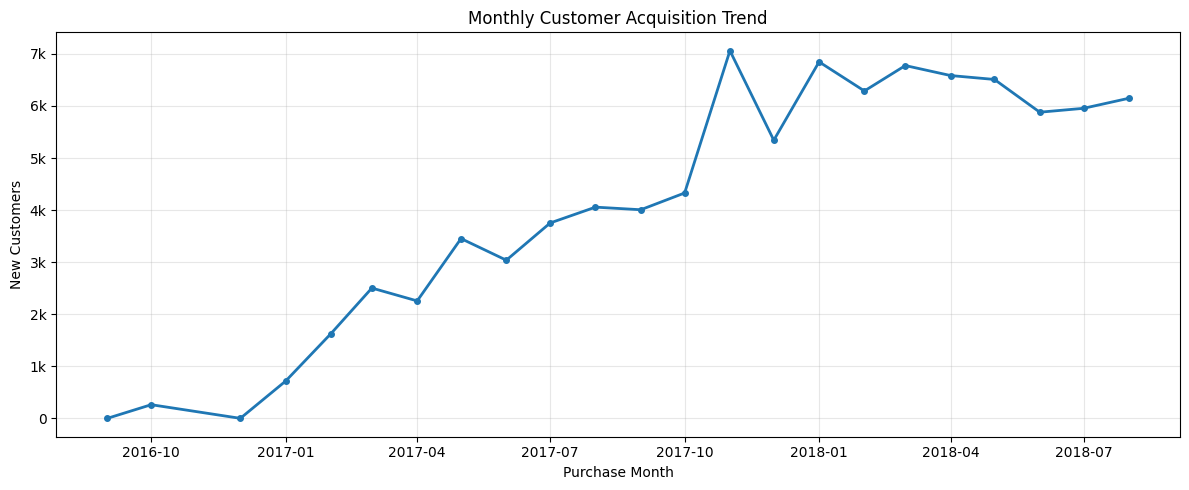

In [ ]:
# ==========================================
# Monthly Customer Acquisition Trend
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    acquisition_df["purchase_month"],
    acquisition_df["new_customers"],
    linewidth=2,
    marker="o",
    markersize=4
)

plt.title("Monthly Customer Acquisition Trend")
plt.xlabel("Purchase Month")
plt.ylabel("New Customers")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, _: f"{int(x/1000)}k" if x >= 1000 else int(x)
    )
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "monthly_customer_acquisition.png",
    bbox_inches="tight"
)

plt.show()

## Monthly Returning Customer Trend

This chart measures how many customers returned after their first purchase.

It helps evaluate retention performance and compare customer growth with returning customer activity.

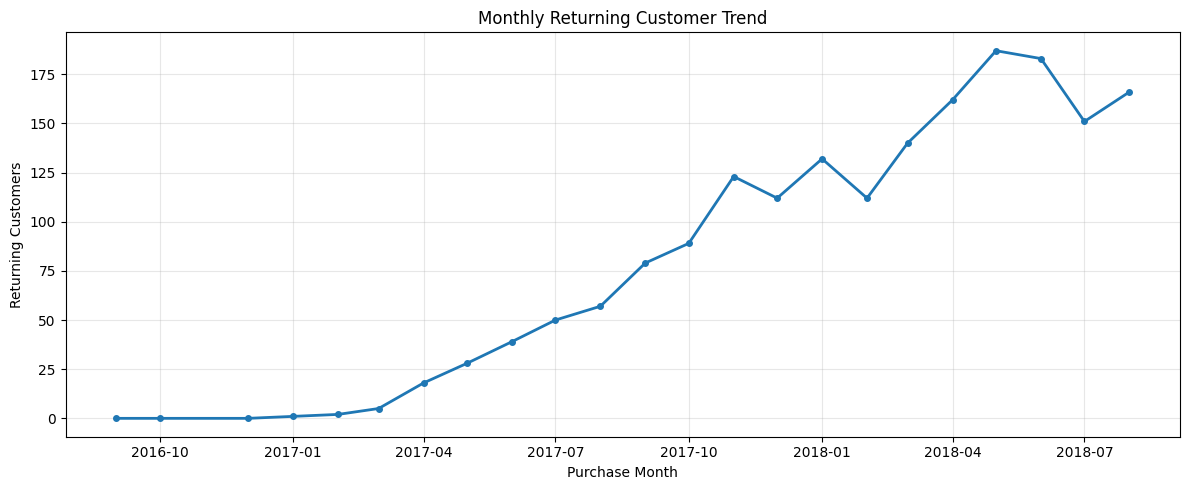

In [ ]:
# ==========================================
# Monthly Returning Customer Trend
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    returning_df["purchase_month"],
    returning_df["returning_customers"],
    linewidth=2,
    marker="o",
    markersize=4
)

plt.title("Monthly Returning Customer Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Returning Customers")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "returning_customer_trend.png",
    bbox_inches="tight"
)

plt.show()

## Customer Cohort Retention Analysis

Cohort retention analysis tracks how many customers returned after their first purchase.

This visualization helps identify retention patterns over time and shows how quickly customers dropped after acquisition.

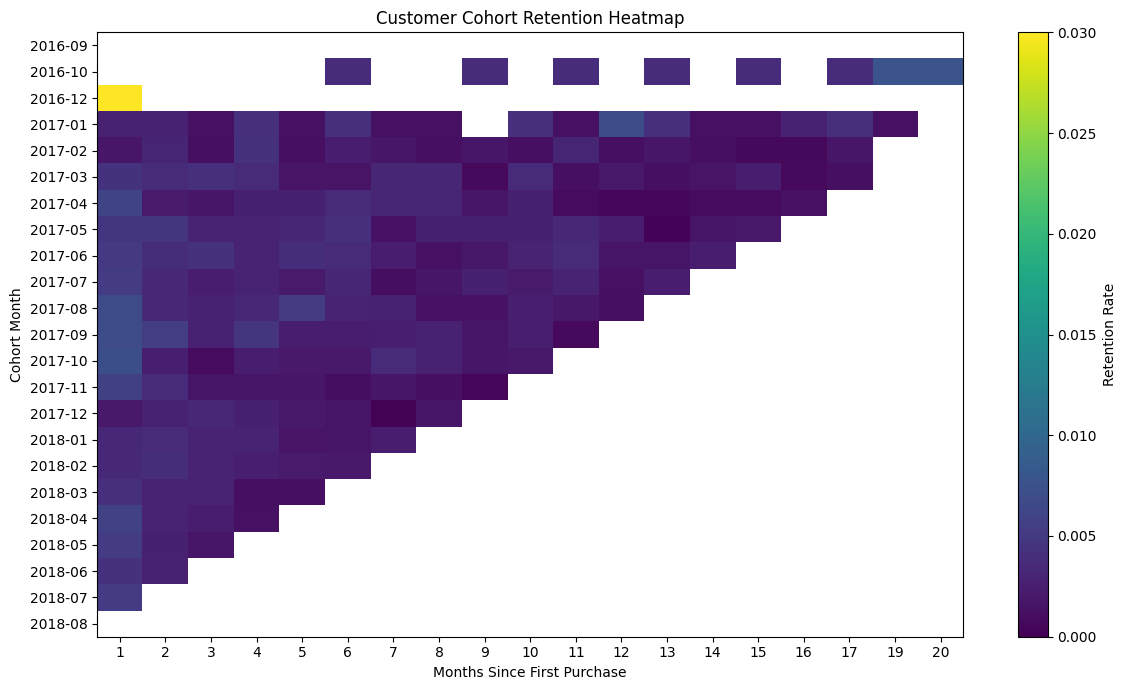

In [ ]:
# ==========================================
# Improved Cohort Retention Heatmap
# ==========================================

# Create pivot table
cohort_pivot = cohort_df.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="total_customers"
)

# Convert to %
cohort_size = cohort_pivot.iloc[:, 0]

retention_matrix = cohort_pivot.divide(
    cohort_size,
    axis=0
)

# Exclude month 0 for visualization
retention_viz = retention_matrix.iloc[:, 1:]

# Plot
plt.figure(figsize=(12, 7))

plt.imshow(
    retention_viz,
    aspect="auto",
    vmin=0,
    vmax=0.03
)

plt.colorbar(label="Retention Rate")

plt.title("Customer Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.xticks(
    range(len(retention_viz.columns)),
    retention_viz.columns
)

plt.yticks(
    range(len(retention_viz.index)),
    retention_viz.index.strftime("%Y-%m")
)

plt.tight_layout()

plt.savefig(
    "cohort_retention_heatmap.png",
    bbox_inches="tight"
)

plt.show()

## RFM Customer Segmentation

RFM segmentation groups customers based on:

- **Recency** → how recently a customer made a purchase
- **Frequency** → how often a customer purchased
- **Monetary** → how much revenue the customer generated

This analysis helps identify high-value customers, repeat buyers, and customers at risk of churn.

In [ ]:
# ==========================================
# Load Customer Master Dataset
# ==========================================

customer_master = pd.read_csv("customer_master.csv")

# Convert dates
customer_master["first_purchase_date"] = pd.to_datetime(
    customer_master["first_purchase_date"]
)

customer_master["last_purchase_date"] = pd.to_datetime(
    customer_master["last_purchase_date"]
)

# Preview
display(customer_master.head())

,customer_unique_id,customer_state,first_purchase_date,last_purchase_date,total_orders,total_revenue,avg_order_value,avg_review_score
0,6e4c8eed6842146f77d917f7b437b4c2,RN,2016-10-04,2016-10-04,1,178.11,178.11,5.0
1,9342b18c97a2bbf3fa9d97aceb0b6dd4,RN,2016-10-06,2016-10-06,1,467.20,467.20,5.0
2,c6b482cd350f5dc9a48ec4c1292c72bd,RN,2016-10-07,2016-10-07,1,41.18,41.18,5.0
3,958df1746c3131f9c7359ae5fb848497,SE,2016-10-07,2016-10-07,1,176.85,176.85,5.0
4,41836ee9834e5c216b28ff121f5d8741,AL,2016-10-07,2016-10-07,1,76.60,76.60,4.0


In [ ]:
# ==========================================
# Calculate Recency
# ==========================================

# Latest date in dataset
snapshot_date = customer_master["last_purchase_date"].max() + pd.Timedelta(days=1)

# Recency = days since last purchase
customer_master["recency"] = (
    snapshot_date - customer_master["last_purchase_date"]
).dt.days

# Preview
display(
    customer_master[
        [
            "customer_unique_id",
            "recency",
            "total_orders",
            "total_revenue"
        ]
    ].head()
)

,customer_unique_id,recency,total_orders,total_revenue
0,6e4c8eed6842146f77d917f7b437b4c2,695,1,178.11
1,9342b18c97a2bbf3fa9d97aceb0b6dd4,693,1,467.20
2,c6b482cd350f5dc9a48ec4c1292c72bd,692,1,41.18
3,958df1746c3131f9c7359ae5fb848497,692,1,176.85
4,41836ee9834e5c216b28ff121f5d8741,692,1,76.60


In [ ]:
# ==========================================
# RFM Scoring
# ==========================================

# Recency (lower is better)
customer_master["r_score"] = pd.qcut(
    customer_master["recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

# Frequency (higher is better)
customer_master["f_score"] = pd.qcut(
    customer_master["total_orders"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary (higher is better)
customer_master["m_score"] = pd.qcut(
    customer_master["total_revenue"],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

# RFM score
customer_master["rfm_score"] = (
    customer_master["r_score"].astype(str)
    + customer_master["f_score"].astype(str)
    + customer_master["m_score"].astype(str)
)

display(
    customer_master[
        [
            "recency",
            "total_orders",
            "total_revenue",
            "rfm_score"
        ]
    ].head()
)

,recency,total_orders,total_revenue,rfm_score
0,695,1,178.11,114
1,693,1,467.20,115
2,692,1,41.18,111
3,692,1,176.85,114
4,692,1,76.60,112


In [ ]:
# ==========================================
# Segment Mapping
# ==========================================

def map_segment(row):

    r = int(row["r_score"])
    f = int(row["f_score"])

    if r >= 4 and f >= 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Others"

customer_master["segment"] = customer_master.apply(
    map_segment,
    axis=1
)

display(
    customer_master["segment"]
    .value_counts()
    .reset_index()
)

,segment,count
0,Others,24781
1,Loyal Customers,19348
2,At Risk,19008
3,Champions,17681
4,Potential Loyalists,12578


## Customer Segment Distribution

This chart shows how customers are distributed across RFM segments.

The distribution helps identify the balance between loyal customers, high-value buyers, and customers at risk of churn.

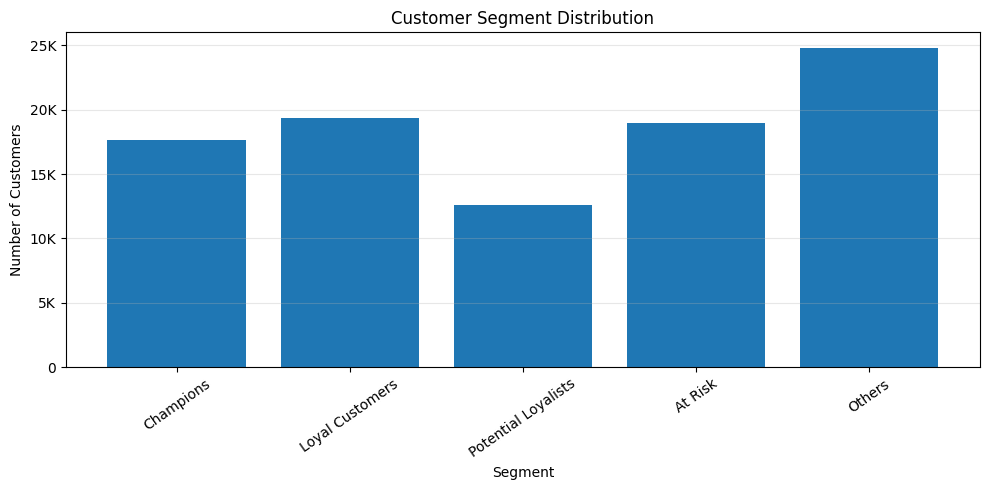

In [ ]:
# ==========================================
# Customer Segment Distribution
# ==========================================

# Count customers by segment
segment_counts = (
    customer_master["segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "segment",
    "count"
]

# Strategic order
segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Others"
]

# Sort order
segment_counts["segment"] = pd.Categorical(
    segment_counts["segment"],
    categories=segment_order,
    ordered=True
)

segment_counts = segment_counts.sort_values("segment")

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    segment_counts["segment"],
    segment_counts["count"]
)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

# Format Y-axis: 5K, 10K, etc.
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, _: f"{int(x/1000)}K" if x >= 1000 else int(x)
    )
)

plt.xticks(rotation=35)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# Save chart
plt.savefig(
    "customer_segment_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Revenue Contribution by Customer Segment

This chart compares revenue contribution across customer segments.

It highlights which customer groups generate the highest business value.

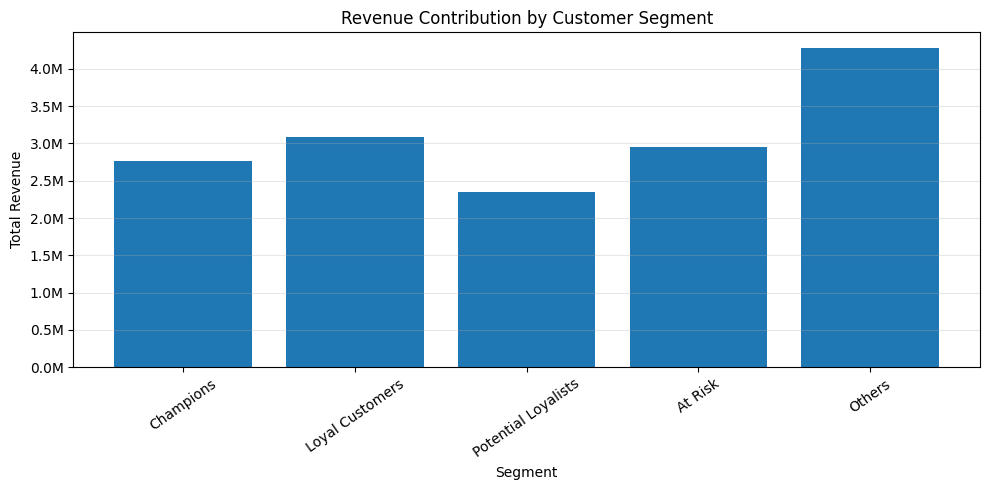

In [ ]:
# ==========================================
# Revenue Contribution by Customer Segment
# ==========================================

# Revenue by segment
segment_revenue = (
    customer_master
    .groupby("segment")["total_revenue"]
    .sum()
    .reset_index()
)

# Strategic order
segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Others"
]

# Sort order
segment_revenue["segment"] = pd.Categorical(
    segment_revenue["segment"],
    categories=segment_order,
    ordered=True
)

segment_revenue = segment_revenue.sort_values("segment")

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    segment_revenue["segment"],
    segment_revenue["total_revenue"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

# Revenue axis format
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, _: f"{x/1_000_000:.1f}M"
    )
)

plt.xticks(rotation=35)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# Save chart
plt.savefig(
    "revenue_by_segment.png",
    bbox_inches="tight"
)

plt.show()

# Key Insights

## 1. Customer acquisition accelerated significantly in late 2017

Monthly new customer acquisition increased steadily throughout 2017 and peaked in November 2017.

This indicates a strong customer growth phase, likely driven by increased platform adoption and sales activity.

---

## 2. Returning customer growth improved over time

Returning customers increased gradually across the observed period.

However, repeat customers remain relatively small compared with total acquisition, indicating that customer retention still has room for improvement.

---

## 3. Cohort retention remained low across most cohorts

The cohort retention heatmap shows that customer return rates dropped sharply after the first purchase.

Most cohorts retained only a small portion of customers in following months.

This suggests customers were more likely to purchase once rather than return consistently.

---

## 4. A large number of customers are categorized as At Risk

RFM segmentation shows a meaningful share of customers are at risk of churn.

This group still contributes significant revenue.

Retaining even a portion of these customers could improve long-term revenue performance.

---

## 5. Revenue is distributed across multiple segments

Revenue contribution is not concentrated only among Champions.

Loyal Customers and At Risk customers also generate substantial revenue.

This suggests retention strategy should focus beyond only top customers.

# Business Recommendations

## Improve repeat purchase campaigns

Retention rates remain low after first purchase.

Personalized email campaigns, discount reminders, and loyalty incentives could encourage customers to return.

---

## Prioritize At Risk customers

At Risk customers still contribute meaningful revenue.

Targeted retention campaigns may reduce churn and recover revenue.

Examples:

- personalized offers
- abandoned-cart reminders
- limited-time discounts

---

## Strengthen customer loyalty programs

Champions and Loyal Customers should receive incentives to stay engaged.

Examples:

- early access promotions
- loyalty rewards
- exclusive offers

---

## Monitor acquisition quality

Customer acquisition is strong.

The next focus should be improving conversion from first-time customers into repeat buyers.

---

## Track retention KPIs regularly

Recommended metrics:

- Repeat customer rate
- Monthly retention
- Cohort retention
- Revenue by segment

# Conclusion

This project analyzed customer behavior and retention using the Brazilian Olist e-commerce dataset.

The analysis shows that customer acquisition grew strongly over time.

However, repeat purchase behavior remained relatively low, and many customers were identified as at risk of churn.

RFM segmentation revealed that customer value is spread across multiple segments.

The findings suggest that improving customer retention and increasing repeat purchases would provide meaningful long-term business value.

# Tools Used

- Google BigQuery (SQL)
- Python (Google Colab)
- Pandas
- Matplotlib
- Google Looker Studio
- GitHub